In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/processed/traffic_density_timeseries.csv")

df.head()

,time_bin_5m,vehicle_count,avg_speed,pce_volume,crawling_count,hard_braking_count
0,2018-10-24 08:30:00,4724,17.826713,4383.0,3427,1419
1,2018-10-24 08:35:00,5106,17.355170,4733.0,3816,1654
2,2018-10-24 08:40:00,3905,16.790361,3633.5,2907,1174
3,2018-10-24 09:00:00,4620,14.779216,4308.0,3809,1441
4,2018-10-24 09:05:00,4983,14.968209,4627.0,4016,1578


In [3]:
df["time_bin_5m"] = pd.to_datetime(df["time_bin_5m"])

df = df.sort_values("time_bin_5m")

df = df.set_index("time_bin_5m")

ts = df["vehicle_count"]

ts.head()

time_bin_5m
2018-10-24 08:30:00    4724
2018-10-24 08:35:00    5106
2018-10-24 08:40:00    3905
2018-10-24 09:00:00    4620
2018-10-24 09:05:00    4983
Name: vehicle_count, dtype: int64

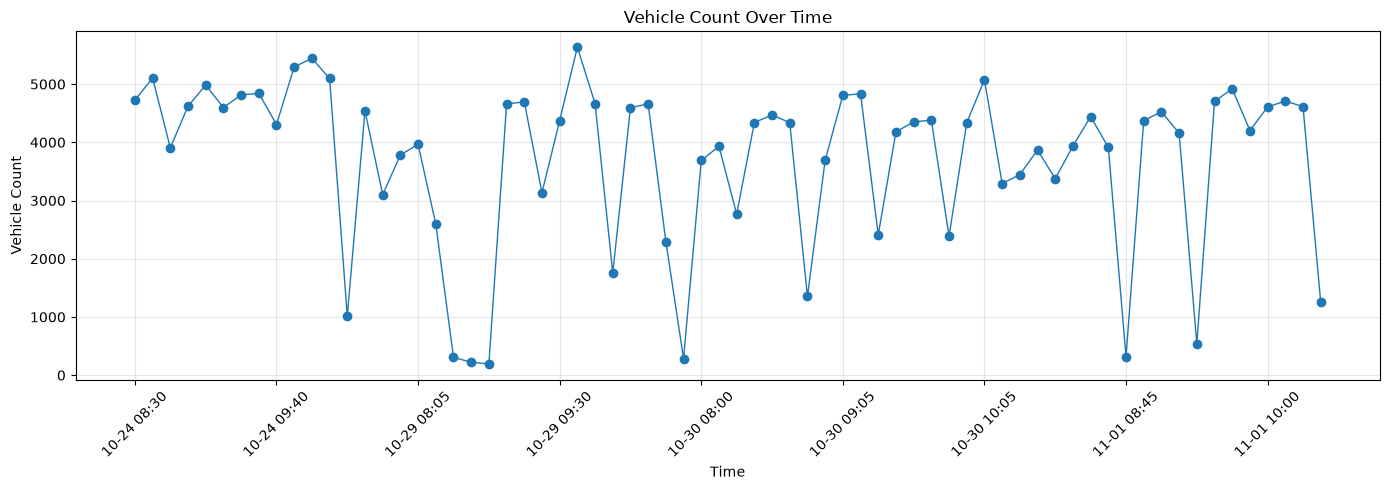

In [4]:
plt.figure(figsize=(14, 5))

x = range(len(ts))

plt.plot(x, ts.values, marker="o", linewidth=1)

tick_positions = range(0, len(ts), max(1, len(ts)//8))
tick_labels = [ts.index[i].strftime("%m-%d %H:%M") for i in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45)

plt.title("Vehicle Count Over Time")
plt.xlabel("Time")
plt.ylabel("Vehicle Count")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Lấy ngày cuối cùng làm tập test
last_day = ts.index.normalize().max()

# 3 ngày đầu làm train
train = ts[ts.index.normalize() < last_day]

# Ngày cuối làm test
test = ts[ts.index.normalize() == last_day]

print("Train samples:", len(train))
print("Test samples :", len(test))

print("\nTrain period:")
print(train.index.min(), "->", train.index.max())

print("\nTest period:")
print(test.index.min(), "->", test.index.max())

Train samples: 50
Test samples : 18

Train period:
2018-10-24 08:30:00 -> 2018-10-30 10:10:00

Test period:
2018-11-01 08:00:00 -> 2018-11-01 10:15:00


In [6]:
result = adfuller(train)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -3.0715998085051104
p-value : 0.028727575953996217


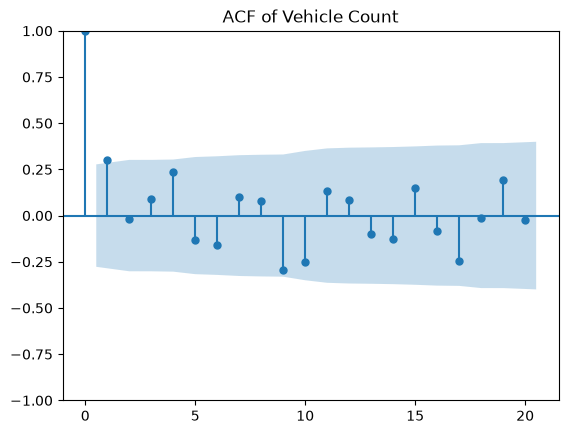

In [7]:
plot_acf(train, lags=20)
plt.title("ACF of Vehicle Count")
plt.show()

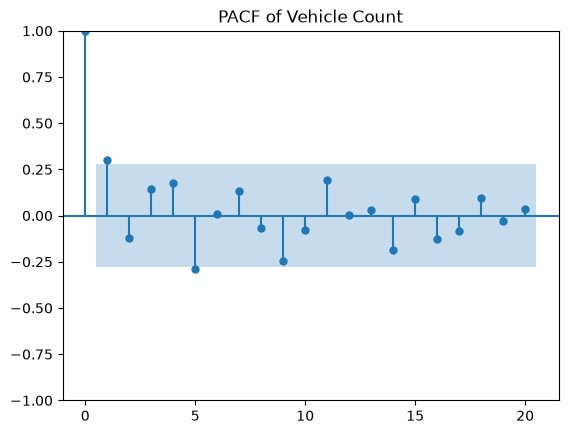

In [8]:
plot_pacf(train, lags=20, method="ywm")
plt.title("PACF of Vehicle Count")
plt.show()

In [9]:
import itertools
import warnings

orders = list(itertools.product(range(0, 4), [0], range(0, 4)))

model_results = []

for order in orders:
    try:
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")

            model = ARIMA(train, order=order)
            model_fit = model.fit()

            forecast_temp = model_fit.forecast(steps=len(test))
            forecast_temp = pd.Series(
                forecast_temp.values,
                index=test.index
            )

            mae = mean_absolute_error(test, forecast_temp)
            rmse = np.sqrt(mean_squared_error(test, forecast_temp))
            mape = mean_absolute_percentage_error(test, forecast_temp) * 100
            r2 = r2_score(test, forecast_temp)

            warning_text = "; ".join([str(warning.message) for warning in w])

            model_results.append({
                "order": order,
                "AIC": model_fit.aic,
                "BIC": model_fit.bic,
                "MAE": mae,
                "RMSE": rmse,
                "MAPE (%)": mape,
                "R2": r2,
                "Warning": warning_text if warning_text else "No warning"
            })

    except Exception as e:
        model_results.append({
            "order": order,
            "AIC": np.nan,
            "BIC": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE (%)": np.nan,
            "R2": np.nan,
            "Warning": str(e)
        })

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by=["RMSE", "AIC"],
    ascending=True
).reset_index(drop=True)

results_df

,order,AIC,BIC,MAE,RMSE,MAPE (%),R2,Warning
0,"(2, 0, 2)",870.256885,881.729023,991.789110,1340.844075,109.783528,0.076572,"A date index has been provided, but it has no ..."
1,"(2, 0, 3)",871.476696,884.860857,1005.135583,1342.843246,109.235269,0.073816,"A date index has been provided, but it has no ..."
2,"(0, 0, 1)",870.761212,876.497281,993.937598,1395.738246,114.903504,-0.000586,"A date index has been provided, but it has no ..."
3,"(1, 0, 1)",872.745808,880.393901,994.162509,1395.763368,114.909100,-0.000622,"A date index has been provided, but it has no ..."
4,"(0, 0, 2)",872.894220,880.542312,994.268286,1395.777373,114.911749,-0.000643,"A date index has been provided, but it has no ..."
5,"(2, 0, 1)",874.619621,884.179736,995.383043,1396.117734,114.945019,-0.001131,"A date index has been provided, but it has no ..."
6,"(2, 0, 0)",872.814700,880.462792,996.444592,1396.126232,114.962536,-0.001143,"A date index has been provided, but it has no ..."
7,"(3, 0, 0)",873.797868,883.357983,991.811046,1396.262519,114.813442,-0.001338,"A date index has been provided, but it has no ..."
8,"(1, 0, 0)",871.540770,877.276839,1002.769810,1396.333614,115.149716,-0.001440,"A date index has been provided, but it has no ..."
9,"(0, 0, 0)",874.274455,878.098501,1008.342278,1397.402329,115.321512,-0.002974,"A date index has been provided, but it has no ..."


In [10]:
valid_results = results_df.dropna(subset=["RMSE", "AIC"]).copy()

best_order = valid_results.iloc[0]["order"]

print("Best ARIMA order:", best_order)

best_model = ARIMA(train, order=best_order)
model_fit = best_model.fit()

print(model_fit.summary())

Best ARIMA order: (2, 0, 2)


d:\DTA_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\DTA_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\DTA_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          vehicle_count   No. Observations:                   50
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -429.128
Date:                Sat, 27 Jun 2026   AIC                            870.257
Time:                        00:51:55   BIC                            881.729
Sample:                             0   HQIC                           874.626
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3728.8914    281.302     13.256      0.000    3177.549    4280.234
ar.L1         -0.2798      0.104     -2.691      0.007      -0.484      -0.076
ar.L2         -0.9125      0.094     -9.751      0.0

d:\DTA_Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
forecast = model_fit.forecast(steps=len(test))

forecast = pd.Series(
    forecast.values,
    index=test.index,
    name="Forecast"
)

d:\DTA_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [12]:
result_df = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

result_df["Error"] = result_df["Actual"] - result_df["Forecast"]

result_df.head()

,Actual,Forecast,Error
time_bin_5m,,,
2018-11-01 08:00:00,3446,3484.110046,-38.110046
2018-11-01 08:05:00,3868,4181.854921,-313.854921
2018-11-01 08:10:00,3376,3825.529524,-449.529524
2018-11-01 08:30:00,3935,3288.522664,646.477336
2018-11-01 08:35:00,4443,3763.911059,679.088941


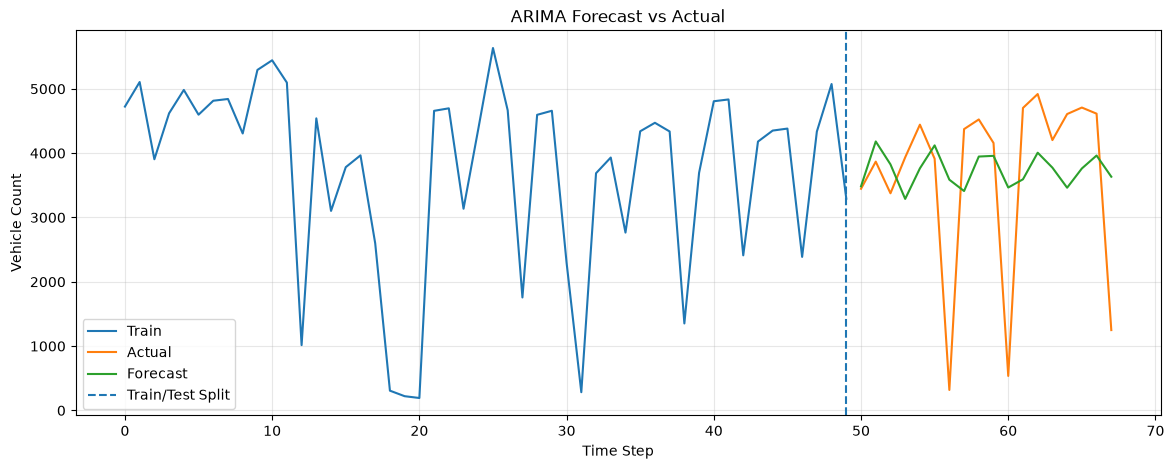

In [13]:
plt.figure(figsize=(14, 5))

x_train = range(len(train))
x_test = range(len(train), len(train) + len(test))

plt.plot(x_train, train.values, label="Train")
plt.plot(x_test, test.values, label="Actual")
plt.plot(x_test, forecast.values, label="Forecast")

plt.axvline(x=len(train)-1, linestyle="--", label="Train/Test Split")

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Vehicle Count")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [14]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = mean_absolute_percentage_error(test, forecast)

r2 = r2_score(test, forecast)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape*100,"%")
print("R2  :", r2)

MAE : 991.7891097332208
RMSE: 1340.8440748522846
MAPE: 109.78352848281729 %
R2  : 0.07657161300859172


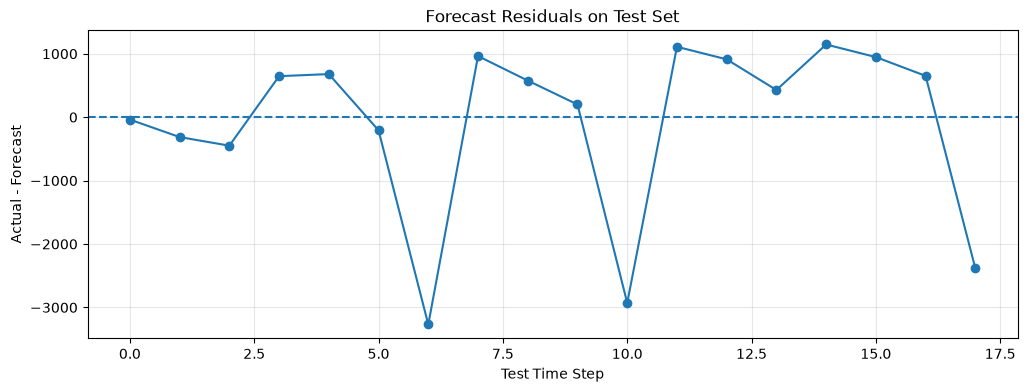

In [15]:
test_residuals = test - forecast

plt.figure(figsize=(12, 4))

plt.plot(range(len(test_residuals)), test_residuals.values, marker="o")
plt.axhline(0, linestyle="--")

plt.title("Forecast Residuals on Test Set")
plt.xlabel("Test Time Step")
plt.ylabel("Actual - Forecast")
plt.grid(True, alpha=0.3)

plt.show()

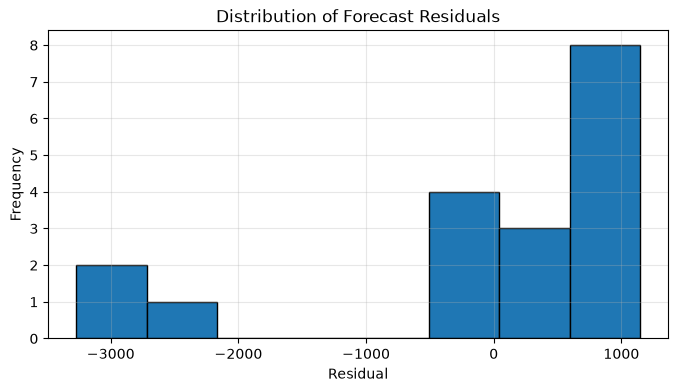

In [16]:
plt.figure(figsize=(8, 4))

plt.hist(test_residuals.dropna(), bins=8, edgecolor="black")

plt.title("Distribution of Forecast Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.show()